<a href="https://colab.research.google.com/github/Amberbops/Notebooks-MP/blob/main/mushroom_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from keras import layers, Sequential
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pandas as pd

In [ ]:
df = pd.read_csv('mushrooms.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'mushrooms.csv'

In [ ]:
df

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l


In [ ]:
df.loc[df['class'] == 'p'].count()['class']

np.int64(3916)

In [ ]:
df.loc[df['class'] == 'e'].count()['class']

np.int64(4208)

In [ ]:
column_names=df.columns.tolist()

In [ ]:
column_names

['class',
 'cap-shape',
 'cap-surface',
 'cap-color',
 'bruises',
 'odor',
 'gill-attachment',
 'gill-spacing',
 'gill-size',
 'gill-color',
 'stalk-shape',
 'stalk-root',
 'stalk-surface-above-ring',
 'stalk-surface-below-ring',
 'stalk-color-above-ring',
 'stalk-color-below-ring',
 'veil-type',
 'veil-color',
 'ring-number',
 'ring-type',
 'spore-print-color',
 'population',
 'habitat']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df.drop('class', axis=1), df['class'], test_size=0.2, random_state=42)
y_train = LabelEncoder().fit_transform(y_train)
y_test = LabelEncoder().fit_transform(y_test)

In [ ]:
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

In [ ]:
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

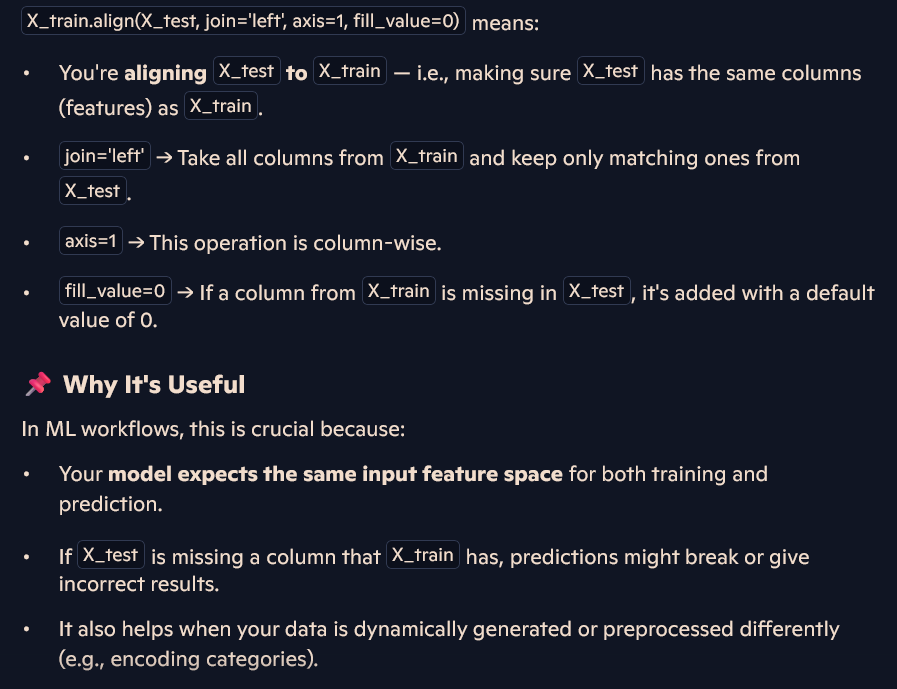

In [ ]:
X_train = StandardScaler().fit_transform(X_train)
X_test = StandardScaler().fit_transform(X_test)

In [ ]:
input_shape = [X_train.shape[1]]

In [ ]:
X_train

array([[-0.23965753, -0.02149006, -0.78348993, ..., -0.40221944,
        -0.21533542, -0.16139978],
       [-0.23965753, -0.02149006, -0.78348993, ...,  2.48620503,
        -0.21533542, -0.16139978],
       [-0.23965753, -0.02149006,  1.27634059, ..., -0.40221944,
        -0.21533542, -0.16139978],
       ...,
       [-0.23965753, -0.02149006,  1.27634059, ...,  2.48620503,
        -0.21533542, -0.16139978],
       [-0.23965753, -0.02149006, -0.78348993, ...,  2.48620503,
        -0.21533542, -0.16139978],
       [-0.23965753, -0.02149006, -0.78348993, ..., -0.40221944,
        -0.21533542, -0.16139978]])

In [ ]:
model = Sequential([
    layers.BatchNormalization(input_shape = input_shape),
    layers.Dense(256, activation = 'relu'),
    layers.Dropout(0.2),
    layers.BatchNormalization(),
    layers.Dense(128, activation = 'relu'),
    layers.Dropout(0.2),
    layers.BatchNormalization(),
    layers.Dense(1, activation = 'sigmoid'),
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/normalization/batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['binary_accuracy'])

In [ ]:
history = model.fit(X_train, y_train, batch_size=128, epochs=50)
history_df = pd.DataFrame(history.history)


Epoch 1/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - binary_accuracy: 0.9021 - loss: 0.2222
Epoch 2/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - binary_accuracy: 0.9992 - loss: 0.0074
Epoch 3/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - binary_accuracy: 1.0000 - loss: 0.0031
Epoch 4/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - binary_accuracy: 0.9999 - loss: 0.0019
Epoch 5/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - binary_accuracy: 1.0000 - loss: 0.0012
Epoch 6/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - binary_accuracy: 1.0000 - loss: 9.7437e-04
Epoch 7/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - binary_accuracy: 1.0000 - loss: 6.8253e-04
Epoch 8/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - binary_accuracy: 1.0000 - loss: 6.6263e-04
Epoch 9/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - binary_accuracy: 1.0000 - loss: 4.5592e-04
Epoch 10/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - binary_accuracy: 1.0000 - loss: 5.4948e-04
Epoch 11/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - binary_accura

In [ ]:
history_df

,binary_accuracy,loss
0,0.966764,0.084854
1,0.999231,0.006213
2,0.999846,0.003040
3,0.999846,0.001843
4,1.000000,0.001175
5,1.000000,0.000836
6,1.000000,0.000614
7,1.000000,0.000739
8,1.000000,0.000422
9,1.000000,0.000438


In [ ]:
X_test

array([[-0.25470668, -0.02481458,  1.17885787, ..., -0.41525736,
        -0.22755205, -0.12998508],
       [-0.25470668, -0.02481458,  1.17885787, ..., -0.41525736,
        -0.22755205, -0.12998508],
       [-0.25470668, -0.02481458, -0.84827868, ..., -0.41525736,
        -0.22755205, -0.12998508],
       ...,
       [-0.25470668, -0.02481458, -0.84827868, ...,  2.40814517,
        -0.22755205, -0.12998508],
       [-0.25470668, -0.02481458, -0.84827868, ...,  2.40814517,
        -0.22755205, -0.12998508],
       [-0.25470668, -0.02481458, -0.84827868, ...,  2.40814517,
        -0.22755205, -0.12998508]])

In [ ]:
preds = model.predict(X_test)

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [ ]:
df_preds = pd.DataFrame(preds, columns=['prediction'])

In [ ]:
df_preds

,prediction
0,5.742381e-07
1,9.999990e-01
2,9.999982e-01
3,1.405414e-06
4,9.999993e-01
...,...
1620,9.999995e-01
1621,1.381728e-06
1622,9.999998e-01
1623,9.999989e-01


In [ ]:
def Classify(df_preds):
  # Use a boolean mask for efficient classification
  df_preds['prediction'] = (df_preds['prediction'] > 0.5).astype(int)
  return df_preds

In [ ]:
Classify(df_preds)

,prediction
0,0
1,1
2,1
3,0
4,1
...,...
1620,1
1621,0
1622,1
1623,1


In [ ]:
df_preds.loc[df_preds['prediction'] == 1].count()


,0
prediction,782


In [ ]:
df_preds.loc[df_preds['prediction'] == 0].count()

,0
prediction,843


In [ ]:
df_preds['prediction'] = df_preds['prediction'].map({0: 'edible', 1: 'poisonous'})

In [ ]:
df_preds

,prediction
0,edible
1,poisonous
2,poisonous
3,edible
4,poisonous
...,...
1620,poisonous
1621,edible
1622,poisonous
1623,poisonous


In [ ]:
# Reconstruct column names for the one-hot encoded DataFrame
original_columns = df.drop('class', axis=1).columns
encoded_column_names = []
for col in original_columns:
    unique_values = df[col].unique()
    for value in unique_values:
        encoded_column_names.append(f"{col}_{value}")

# Create the DataFrame from the scaled X_test NumPy array using the reconstructed column names
X_test_df = pd.DataFrame(X_test, columns=encoded_column_names)

# Now merge with the predictions DataFrame
Final_df = pd.merge(X_test_df, df_preds, left_index=True, right_index=True)

display(Final_df.head())

,cap-shape_x,cap-shape_b,cap-shape_s,cap-shape_f,cap-shape_k,cap-shape_c,cap-surface_s,cap-surface_y,cap-surface_f,cap-surface_g,...,population_y,population_c,habitat_u,habitat_g,habitat_m,habitat_d,habitat_p,habitat_w,habitat_l,prediction
0,-0.254707,-0.024815,1.178858,-0.307044,-0.055556,-0.869918,1.558291,-0.024815,-0.674381,-0.808148,...,-1.011761,-0.512471,-0.800883,1.659183,-0.322398,-0.192389,-0.415257,-0.227552,-0.129985,edible
1,-0.254707,-0.024815,1.178858,-0.307044,-0.055556,-0.869918,-0.641729,-0.024815,1.482841,-0.808148,...,0.988375,-0.512471,-0.800883,-0.602706,3.101760,-0.192389,-0.415257,-0.227552,-0.129985,poisonous
2,-0.254707,-0.024815,-0.848279,-0.307044,-0.055556,1.149534,-0.641729,-0.024815,-0.674381,1.237398,...,0.988375,-0.512471,-0.800883,-0.602706,3.101760,-0.192389,-0.415257,-0.227552,-0.129985,poisonous
3,-0.254707,-0.024815,1.178858,-0.307044,-0.055556,-0.869918,-0.641729,-0.024815,-0.674381,1.237398,...,-1.011761,1.951331,1.248621,-0.602706,-0.322398,-0.192389,-0.415257,-0.227552,-0.129985,edible
4,-0.254707,-0.024815,1.178858,-0.307044,-0.055556,-0.869918,-0.641729,-0.024815,1.482841,-0.808148,...,0.988375,-0.512471,-0.800883,-0.602706,3.101760,-0.192389,-0.415257,-0.227552,-0.129985,poisonous
